In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

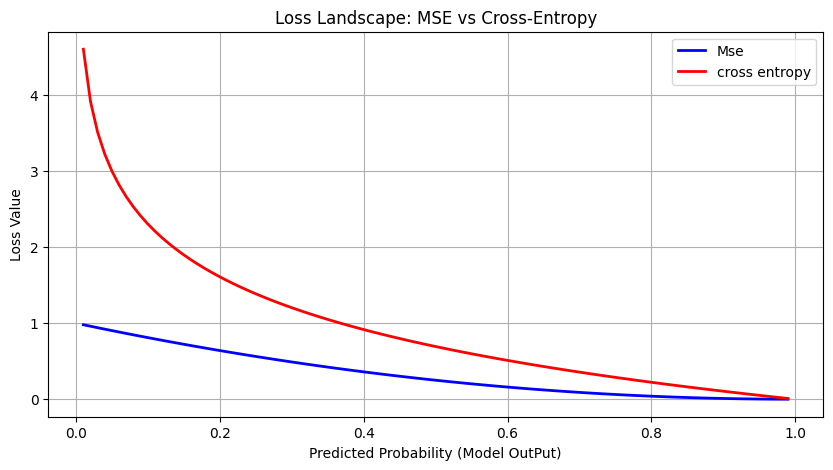

In [3]:
p = torch.linspace(0.01, 0.99, 100)
target = torch.tensor([1.0])

# 1. MSE
mse_loss = (target - p) ** 2

# 2. Cross-Entropy loss
ce_loss = -torch.log(p)

# 시각화
plt.figure(figsize=(10, 5))

plt.plot(p.numpy(), mse_loss.numpy(), label='Mse', color='blue', lw=2)
plt.plot(p.numpy(), ce_loss.numpy(), label='cross entropy', color='red', lw=2)

plt.title("Loss Landscape: MSE vs Cross-Entropy")
plt.xlabel('Predicted Probability (Model OutPut)')
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 1. 실험을 위한 깊은 신경망 모델을 정의
class DeepNet (nn.Module):
    def __init__(self, activation_fn):
        super(DeepNet, self).__init__()
        # 10개의 행을 쌓아 기울기가 전달되는 과정을 관찰할 겁니다.
        layers = []
        for i in range(10):
            layers.append(nn.Linear(10, 10))
            layers.append(activation_fn)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [11]:
# 2. 기울기 흐듬 분석 함수
def analyze_gradients(activation_name, activation_fn):
    model = DeepNet(activation_fn)

    # 임의의 입력 데이터와 정답 데이터를 생성
    x = torch.randn(1, 10)
    target = torch.randn(1, 10)

    # 손실 계산
    output = model(x)
    loss = nn.MSELoss() (output, target)

    # 역전파
    model.zero_grad()
    loss.backward()

    # 각 층(Linear Layer)의 기율기 크기(평균 절대값) 수집
    gradient = []
    for layer in model.model:
        if isinstance( layer, nn.Linear):
            # 기울기의 평균 절대값을 저장
            gradient.append(layer.weight.grad.abs().mean().item())
    return gradient

In [12]:
grads_sigmoid = analyze_gradients("Sigmoid", nn.Sigmoid())
grads_relu = analyze_gradients("ReLU", nn.ReLU())
print(grads_relu)
print(grads_sigmoid)

[1.7868582290248014e-05, 1.5566205547656864e-05, 1.1437195098551456e-05, 7.790720701450482e-06, 5.893757406738587e-05, 0.00016789928486105055, 0.0002729821717366576, 0.00030621804762631655, 0.0007010200060904026, 0.013120299205183983]
[3.9262951223584253e-10, 8.921298699782199e-10, 8.464789758022562e-09, 6.008961150882897e-08, 4.114996841053653e-07, 2.1431715140352026e-06, 2.0693198166554794e-05, 0.00022279104450717568, 0.003999093547463417, 0.01748068258166313]


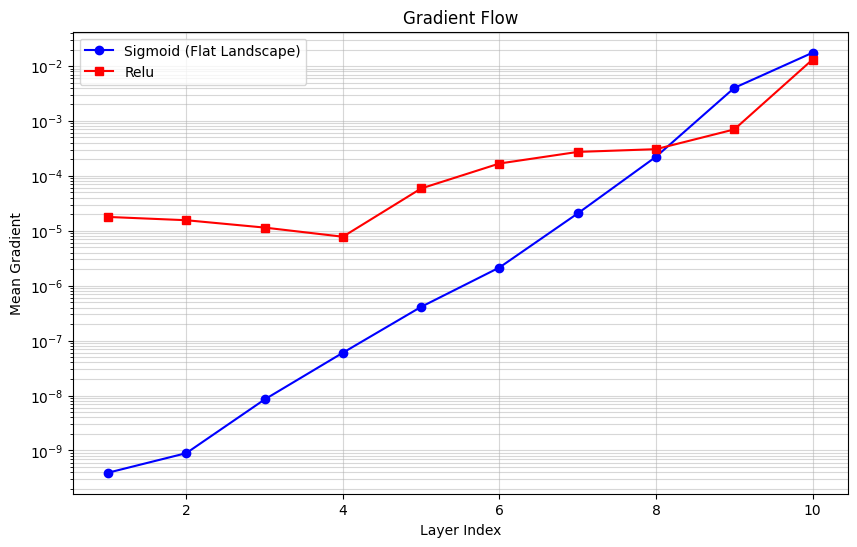

In [17]:
# 4. 시각화: 층이 깊어질수록 기울기가 어떻게 변하는가?
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), grads_sigmoid, marker='o', label='Sigmoid (Flat Landscape)', color='blue')
plt.plot(range(1, 11), grads_relu, marker='s', label='Relu', color='red')

plt.title('Gradient Flow')
plt.xlabel('Layer Index')
plt.ylabel('Mean Gradient')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', ls='-', alpha=0.5)

plt.show()

In [18]:
import torch

# 1. 입력값 설정 (기울기를 계산하기 위해서 requires_grad=True 설정)
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(3.0, requires_grad=True)
x3 = torch.tensor(1.0, requires_grad=True)

# 2. 순전파
m = x1 * x2 # 곱셈 노드
s = m + x3 # 덧셈 노드
y = s ** 2 # 제급 노드

print(f"순전파 결과 (y): {y.item()}")

# 3. 역전파
y.backward()

print(f"x1의 기울기 (dL/dx1): {x1.grad}")
print(f"x2의 기울기 (dL/dx2): {x2.grad}")
print(f"x3의 기울기 (dL/dx1): {x3.grad}")

순전파 결과 (y): 49.0
x1의 기울기 (dL/dx1): 42.0
x2의 기울기 (dL/dx2): 28.0
x3의 기울기 (dL/dx1): 14.0


In [21]:
import torch
# 경사하강법을 이용한 가종치 업데이트

# 가상의 데이터를 만들어 봅시다.
X = torch.tensor([[1.0], [2.0], [3.0]])
Y = torch.tensor([[2.0], [4.0], [6.0]])

# 모밀 파라미터 초기화
w = torch.tensor([[0.0]], requires_grad=True)
learning_rate = 0.1

# 학습 시작
for epoch in range( 10):
    pred = X @ w
    loss = torch.mean( (pred - Y) ** 2)
    loss.backward()

    with torch.no_grad( ):
        w -= learning_rate * w.grad
    w.grad.zero_()

    print(f"Epoch {epoch + 1}: Loss = {loss.item() : .4f}, w = {w.item(): .4f}")

print(f"최종 학습된 가중치 w: {w.item() : .4f}")

Epoch 1: Loss =  18.6667, w =  1.8667
Epoch 2: Loss =  0.0830, w =  1.9911
Epoch 3: Loss =  0.0004, w =  1.9994
Epoch 4: Loss =  0.0000, w =  2.0000
Epoch 5: Loss =  0.0000, w =  2.0000
Epoch 6: Loss =  0.0000, w =  2.0000
Epoch 7: Loss =  0.0000, w =  2.0000
Epoch 8: Loss =  0.0000, w =  2.0000
Epoch 9: Loss =  0.0000, w =  2.0000
Epoch 10: Loss =  0.0000, w =  2.0000
최종 학습된 가중치 w:  2.0000
